In [1]:
import sys

sys.path.insert(0, '../src')

import matplotlib.pyplot as plt

from typing import Any
from feature_extractor import GeometricFeatureExtractor
from icp import ICP, MultiStartICP
from experiment_runner import fit_multi_seed
from matcher import NearestNeighborMatcher
from error_metrics import convergence_to_global_opt_ratio, convergence_ratio
from visualization import ErrorMetricsVisualizer, TimeVisualizer

from tabulate import tabulate

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 50
N_STARTS = 20

In [2]:
# 1. MultiICP with appending of geometric features in gaussian matcher
from algebra_utils import sample_dispersed_rotations

extractor = GeometricFeatureExtractor(k=46)
matcher = NearestNeighborMatcher(feature_extractor=extractor, beta=0.005395)
single_icp = ICP(matcher=matcher, max_iter=MAX_ITER, record_history=False)
icp = MultiStartICP(single_icp, n_starts=N_STARTS, rotation_sampler=sample_dispersed_rotations)

In [3]:
experiment_kwargs: dict[str, Any] = {'n': 500, 'noise_std': 0.1, 't_scale': 8.0, 'style': 'muscle-fiber'}
ms_result1 = fit_multi_seed(icp, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs, n_jobs=-1)

Solving 50 seeds: 100%|██████████| 50/50 [17:08<00:00, 20.56s/it]  


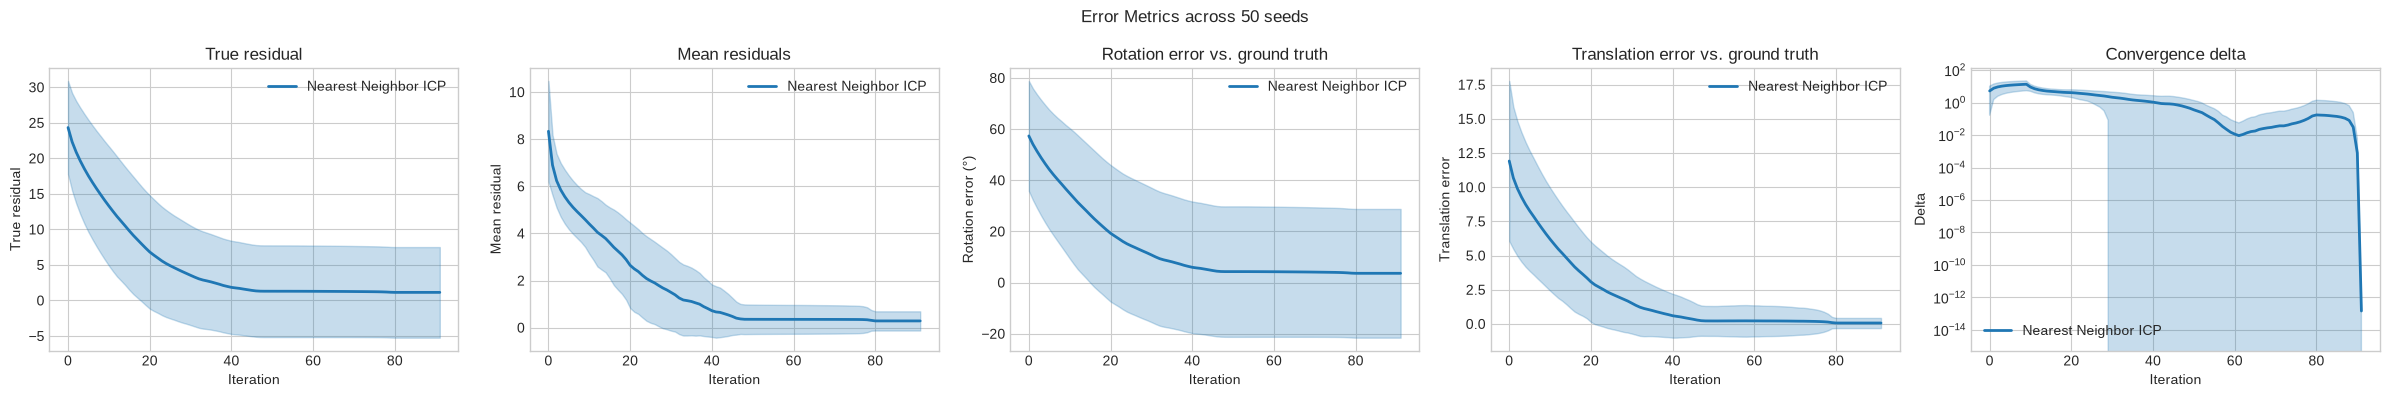

In [4]:
ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[ms_result1.results], 
    experiments_per_method=[ms_result1.experiments], 
    method_labels=["Nearest Neighbor ICP"]
)
plt.suptitle(f"Error Metrics across {N_SEEDS} seeds")
plt.tight_layout()
plt.savefig('../results/8_rainbow_ICP_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import numpy as np

rows: list[tuple[str, Any, Any, Any, Any]] = [
    ("Method", "Convergence Ratio", "Global Optimum Ratio", "Final Rotation Errors (°)", "Final Translation Errors"),
    ("Nearest Neighbor ICP", convergence_ratio(ms_result1.results), convergence_to_global_opt_ratio(ms_result1.results, tol=0.5), f"{np.mean(ms_result1.rotation_errors):.2f} +- {np.std(ms_result1.rotation_errors):.2f}", f"{np.mean(ms_result1.translation_errors):.2f} +- {np.std(ms_result1.translation_errors):.2f}"),
]

print(tabulate(rows, headers="firstrow", tablefmt="rounded_grid", floatfmt=".4f"))

╭──────────────────────┬─────────────────────┬────────────────────────┬─────────────────────────────┬────────────────────────────╮
│ Method               │   Convergence Ratio │   Global Optimum Ratio │ Final Rotation Errors (°)   │ Final Translation Errors   │
├──────────────────────┼─────────────────────┼────────────────────────┼─────────────────────────────┼────────────────────────────┤
│ Nearest Neighbor ICP │              1.0000 │                 0.9800 │ 3.62 +- 25.17               │ 0.06 +- 0.37               │
╰──────────────────────┴─────────────────────┴────────────────────────┴─────────────────────────────┴────────────────────────────╯


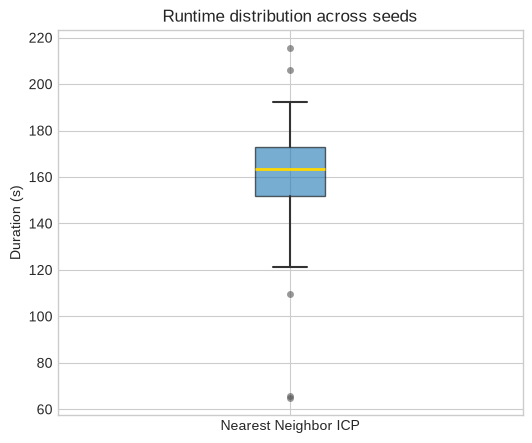

In [6]:
fix, axes = plt.subplots(1, 1, figsize=(6, 5))

TimeVisualizer.plot_duration_distribution(
    ax=axes,
    durations_per_method=[np.array(ms_result1.durations_s)], 
    method_labels=["Nearest Neighbor ICP"]
    )
plt.show()